ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [ ]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

The dataset contains an extreme outlier (500), which can heavily distort the mean and standard deviation. The median and IQR are resistant to outliers and better represent the typical customer spending. Most values lie between 30 and 35, which the median captures accurately. Mean and standard deviation would give a misleading impression of higher average spending. Therefore, median and IQR provide a more robust summary for this dataset.

In [ ]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1 = np.array(data_q1)
sorted_data = np.sort(data_q1)
print(sorted_data)
median = np.median(data_q1)
print(median)
q1 = np.percentile(data_q1, 25)
q3 = np.percentile(data_q1, 75)
iqr = q3 - q1
print(iqr)

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
print(lower_fence)
print(upper_fence)

outlier = sorted_data[(sorted_data > upper_fence) | (sorted_data<lower_fence)]
print(outlier)

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

If the prevalence increases to 20%, the PPV will increase. This is because a larger proportion of the population actually has the disease, so a positive test result is more likely to be a true positive. In Bayes’ formula, increasing
P(D)
P(D) increases the numerator faster than the false-positive term in the denominator. As a result, the probability that a positive test indicates real disease becomes higher.

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

1. This is a supervised binary classification problem, since the target variable premium_user has two possible values (0 or 1).

2. Reasonable Preprocessing Steps
Handle missing values in numeric and categorical columns
Encode the categorical variable region (e.g., one-hot encoding)
Scale or normalize numeric features such as age and daily_clicks
Check for and handle outliers in numeric features.

3. End-to-End ML Pipeline (6–8 sentences)
First, I would explore the dataset to understand feature distributions, missing values, and class balance in the target variable. Next, missing values would be handled using appropriate imputation methods for numeric and categorical features. The region column would be encoded using one-hot encoding so it can be used by machine learning models. Numeric features such as age and daily_clicks would be scaled to ensure comparable ranges. The data would then be split into training and test sets to avoid data leakage. A suitable classification model such as logistic regression or a decision tree would be trained on the training data.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [ ]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

missing_value = df.isna().sum()
print("Missing value:", missing_value)

unique_values = df.nunique()
print("Unique value:", unique_values)

corelation = df.corr(numeric_only=True)
print("Co relation",corelation)

In [ ]:
#  Histogram of purchases
plt.hist(df["purchases"].dropna())
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.title("Histogram of Purchases")
plt.show()


In [ ]:
# Bar chart for region frequency
df["region"].value_counts().plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Region Frequency")
plt.show()

_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [ ]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2



In [12]:
# train test spilit
X = df2[["area_sqft", "bedrooms"]]
y = df2["price"]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42);
model = LinearRegression()
model.fit(x_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
y_pred = model.predict(x_test)
print("Predictions:", y_pred)

Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Predictions: [100.         130.76923077]


In [14]:
# evaluation metrics on test
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)
r2 = r2_score(y_test, y_pred)
print("R squared:", r2)

Mean Absolute Error: 19.615384615384613
Root Mean Squared Error: 19.61915499208746
R squared: -0.7107166337935567


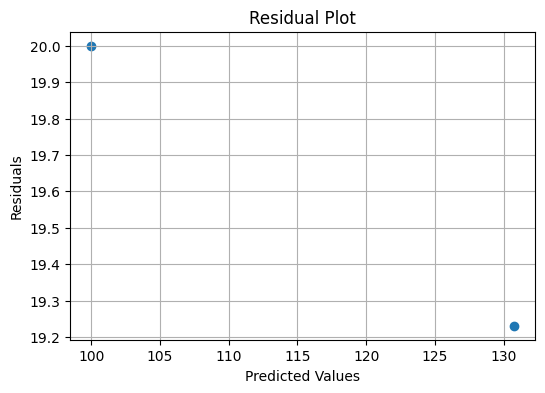

In [15]:
# resudual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [17]:
from matplotlib import cm
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below
y_pred_05 = (y_prob >= 0.5).astype(int)
cm_05 = confusion_matrix(y_true, y_pred_05)
prec_05 = precision_score(y_true, y_pred_05)
rec_05 = recall_score(y_true, y_pred_05)
f1_05 = f1_score(y_true,y_pred_05)
cm_05, prec_05, rec_05, f1_05

(array([[5, 0],
        [0, 5]]),
 1.0,
 1.0,
 1.0)

In [18]:
# threshold
y_pred_03 = (y_prob >= 0.3).astype(int)

cm_03 = confusion_matrix(y_true, y_pred_03)
prec_03 = precision_score(y_true, y_pred_03)
rec_03 = recall_score(y_true, y_pred_03)
f1_03 = f1_score(y_true, y_pred_03)

cm_03, prec_03, rec_03, f1_03


(array([[3, 2],
        [0, 5]]),
 0.7142857142857143,
 1.0,
 0.8333333333333334)

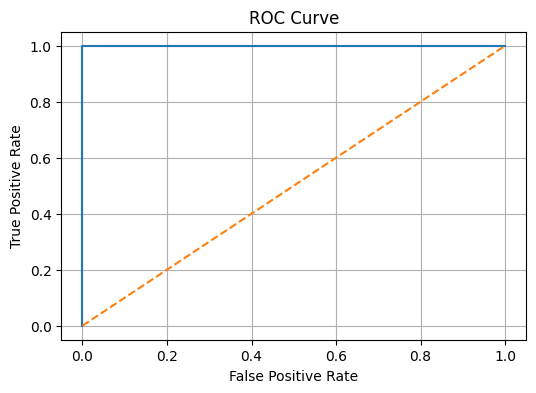

In [19]:
# roc curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [20]:
# AUC
auc_value = auc(fpr, tpr)
print("AUC:", round(auc_value, 3))

AUC: 1.0


In [22]:
# decision tree
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

df3

# Fit Decision Tree

X = df3[["hours"]]
y = df3["passed"]
model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)


DecisionTreeClassifier(max_depth=2)

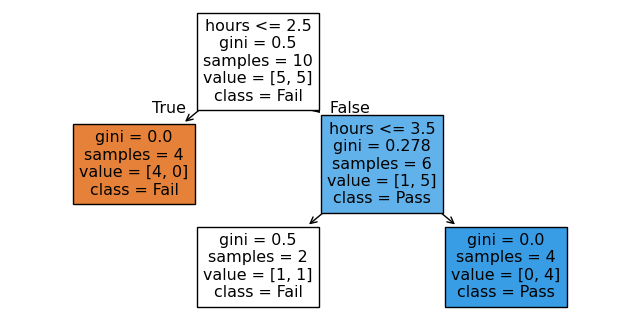

In [24]:
# Plot the tree
plt.figure(figsize=(8,4))
plot_tree(
    model,
    feature_names=["hours"],
    class_names=["Fail", "Pass"],
    filled=True
)
plt.show()


_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._